In [96]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from matplotlib import pyplot as plt
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv('https://www.spc.noaa.gov/wcm/data/1950-2021_actual_tornadoes.csv')
# making data column date type
df['date'] = pd.to_datetime(df['date'])
df['month'] = df.date.dt.month
df['year'] = df.date.dt.year
df.head()

### 1. Aggregate the tornado data over the following states into a monthly count of tornadoes

In [4]:
# Illinois Indiana Wisconsin Michigan Missouri Iowa Minnesota
# creating month column
df['month'] = df.date.dt.month
grp_df = (df[df['st'].isin(['IL'])][
            ['st','year','month']].groupby(['year','month'])
            .count().reset_index())
grp_df.rename(columns={'st':'cnt'},inplace=True)
grp_df['date'] = (pd.to_datetime(grp_df['year'].astype(str) + '-'+\
                  grp_df['month'].astype(str).str.zfill(2) + '-' + '01'))
grp_df

,year,month,cnt,date
0,1950,1,2,1950-01-01
1,1950,3,1,1950-03-01
2,1950,6,1,1950-06-01
3,1950,7,1,1950-07-01
4,1950,12,3,1950-12-01
...,...,...,...,...
440,2021,6,15,2021-06-01
441,2021,7,8,2021-07-01
442,2021,8,16,2021-08-01
443,2021,10,10,2021-10-01


### 2. Merge this monthly tornado dataset with the ENSO, MJO, NAO, and AO dataframe created in Module 4 Notebook 1.

In [5]:
wea_df = pd.read_csv('hw_data.csv')
wea_df['Date'] = pd.to_datetime(wea_df['Date'])
wea_df.rename(columns={'Date':'date'},inplace=True)
wea_df.head()

,date,ENSO,PDO,NAO,AO
0,1951-01-01,1.5,-1.19,0.08,-0.085
1,1951-02-01,0.9,-1.52,0.70,-0.400
2,1951-03-01,-0.1,-1.72,-1.02,-1.934
3,1951-04-01,-0.3,-1.35,-0.22,-0.776
4,1951-05-01,-0.7,-1.29,-0.59,-0.863


In [6]:
all_df = pd.merge(wea_df,grp_df,on='date',how='inner')
all_df.tail()

,date,ENSO,PDO,NAO,AO,year,month,cnt
435,2021-06-01,0.4,-1.82,0.77,0.845,2021,6,15
436,2021-07-01,1.4,-2.00,0.03,0.630,2021,7,8
437,2021-08-01,0.6,-0.95,-0.28,-0.209,2021,8,16
438,2021-10-01,0.7,-3.13,-2.29,-0.146,2021,10,10
439,2021-12-01,1.5,-2.71,0.29,0.198,2021,12,8


In [91]:
all_df.isnull().sum()

date     0
ENSO     0
PDO      0
NAO      0
AO       0
year     0
month    0
cnt      0
dtype: int64

### 3. Create a random forest regression model and use features that include the 4 climate indices to predict the monthly number of tornadoes. Create a scatter plot of the predicted and observed number of tornadoes over these states. Report the correlation coefficient and RMSE of your model.

In [88]:
data_col = ['ENSO','PDO','NAO','AO','month']
X = all_df[data_col]
y = all_df['cnt']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [89]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=42)

In [90]:
model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [80]:
pred_rf = model_rf.predict(X_test)

In [81]:
# rmse on test data
root_mean_squared_error(y_test, pred_rf)

11.48530647273843

In [82]:
pred_all = model_rf.predict(X)

In [83]:
# rmse on all data
root_mean_squared_error(y, pred_all)

5.779086177368749

In [84]:
# correlation
np.corrcoef(np.array(y),pred_all)[0][1]

np.float64(0.7477401283473735)

In [65]:
len(y)

440

In [85]:
len(pred_all)

440

Text(0, 0.5, 'Predicted count')

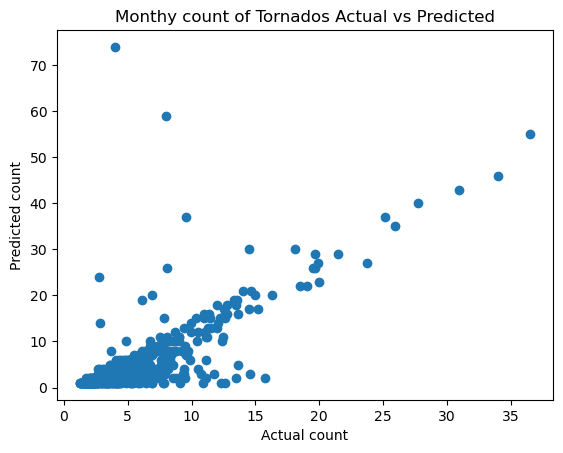

In [95]:
plt.scatter(pred_all,y)
plt.title("Monthy count of Tornados Actual vs Predicted")
plt.xlabel('Actual count')
plt.ylabel('Predicted count')

### 4. Create a one-hot encoding for the month of the year. Repeat the scatterplot and compare the RMSE and correlation coefficient values